# EDA For Ecommerce Recommendations

Ноутбук собран как основной аналитический артефакт проекта. Цель анализа: показать, почему на этом датасете recommendation pipeline строится вокруг `addtocart`, time-based evaluation и memory-safe retrieval-логики, а не вокруг тяжёлых dense-представлений.

В исходных данных `events.csv` содержит 2,756,101 событий, а объединённый `item_properties` — 20,275,902 строк. Поэтому для ревью важны не только выводы по качеству, но и дисциплина работы с памятью и промежуточными артефактами.


In [23]:
from pathlib import Path
import json
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import date2num
from matplotlib.ticker import FuncFormatter, PercentFormatter
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['legend.frameon'] = False
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

ROOT = Path.cwd().resolve()
if not (ROOT / 'artifacts').exists():
    ROOT = ROOT.parent

with (ROOT / 'eda_summary.json').open(encoding='utf-8') as f:
    eda_summary = json.load(f)
with (ROOT / 'artifacts' / 'reports' / 'eda_notebook_report.json').open(encoding='utf-8') as f:
    notebook_report = json.load(f)

events = pd.read_parquet(ROOT / 'artifacts' / 'data' / 'events_prepared.parquet', columns=['timestamp', 'visitorid', 'event', 'itemid'])
aggregated_train = pd.read_parquet(ROOT / 'artifacts' / 'data' / 'aggregated_train.parquet')
item_snapshot = pd.read_parquet(ROOT / 'artifacts' / 'data' / 'item_snapshot.parquet')

events['datetime'] = pd.to_datetime(events['timestamp'], unit='ms')
events['month'] = events['datetime'].dt.to_period('M').dt.to_timestamp()

COLORS = {
    'view': '#4C78A8',
    'addtocart': '#F58518',
    'transaction': '#54A24B',
    'history_baseline': '#4C78A8',
    'hybrid_history_item2item': '#F58518',
    'weighted_item2item': '#72B7B2',
    'global_popularity': '#9D755D',
}

def fmt_int(value):
    return f'{int(value):,}'

def fmt_pct(value, digits=2):
    return f'{value:.{digits}f}%'

def style_table(df, formats=None, gradient_subset=None):
    _ = gradient_subset
    formatters = {}
    for column, formatter in (formats or {}).items():
        if callable(formatter):
            formatters[column] = formatter
            continue
        formatters[column] = (
            lambda value, spec=formatter: spec.format(value)
            if isinstance(value, (int, float, np.integer, np.floating)) and not pd.isna(value)
            else value
        )
    styler = (
        df.style
        .hide(axis='index')
        .format(formatters)
        .set_properties(**{'text-align': 'left', 'padding': '6px 10px'})
        
    )
    return styler

def annotate_barh(ax, formatter, pad_fraction=0.015):
    xmin, xmax = ax.get_xlim()
    pad = (xmax - xmin) * pad_fraction
    for patch in ax.patches:
        value = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        ax.text(value + pad, y, formatter(value), va='center', ha='left', fontsize=10, color='#1F2937')

def shorten_items(items, limit=4):
    items = list(items)
    head = ', '.join(str(x) for x in items[:limit])
    return head if len(items) <= limit else f'{head}, ...'


## 1. Данные и масштаб

Анализ намеренно опирается на compact parquet/json artifacts, а не на raw full join. Это сохраняет связь с production-пайплайном: в ноутбуке используются те же сущности, которые потом участвуют в ETL, offline evaluation и serving.


In [ ]:
overview = pd.DataFrame(notebook_report['dataset_overview']).rename(columns={
    'table': 'Источник',
    'rows': 'Строк',
    'comment': 'Роль в проекте',
})
scale_table = pd.DataFrame([
    {'Метрика': 'Уникальные пользователи в events', 'Значение': eda_summary['uniques']['users']},
    {'Метрика': 'Уникальные товары в events', 'Значение': eda_summary['uniques']['items_in_events']},
    {'Метрика': 'Уникальные товары в item_properties', 'Значение': eda_summary['uniques']['items_in_properties']},
    {'Метрика': 'Уникальные свойства в item_properties', 'Значение': eda_summary['uniques']['properties']},
    {'Метрика': 'Уникальные transaction id', 'Значение': eda_summary['uniques']['transactions']},
])
footprint = pd.DataFrame(notebook_report['memory_footprint']).rename(columns={
    'frame': 'Артефакт',
    'rows': 'Строк',
    'memory_mb': 'Память, МБ',
})

display(style_table(overview, formats={'Строк': '{:,.0f}'}))
display(style_table(scale_table, formats={'Значение': '{:,.0f}'}))


Источник,Строк,Роль в проекте
events.csv,"2,756,101",сырой событийный лог
category_tree.csv,"1,669",иерархия категорий
item_properties_part1+part2.csv,"20,275,902",исторические свойства товаров


Метрика,Значение
Уникальные пользователи в events,"1,407,580"
Уникальные товары в events,"235,061"
Уникальные товары в item_properties,"417,053"
Уникальные свойства в item_properties,"1,104"
Уникальные transaction id,"17,672"


**Выводы блока**

- Событийный лог содержит 2,756,101 строк, тогда как `item_properties` — 20,275,902; это делает полный join нерабочим по цене памяти и времени.
- Пространство взаимодействий сразу разрежено: 1,407,580 пользователей на 235,061 товаров.


## 2. Почему таргетируется именно `addtocart`

Для рекомендательной задачи нужен сигнал, который уже отражает намерение, но не исчезает из лога почти полностью. `Addtocart` на этом датасете как раз находится между очень шумным `view` и слишком редким `transaction`.


Подпись события,Строк,"Доля, %"
Просмотр,"2,664,312",96.67%
Добавление в корзину,"69,332",2.52%
Покупка,"22,457",0.81%


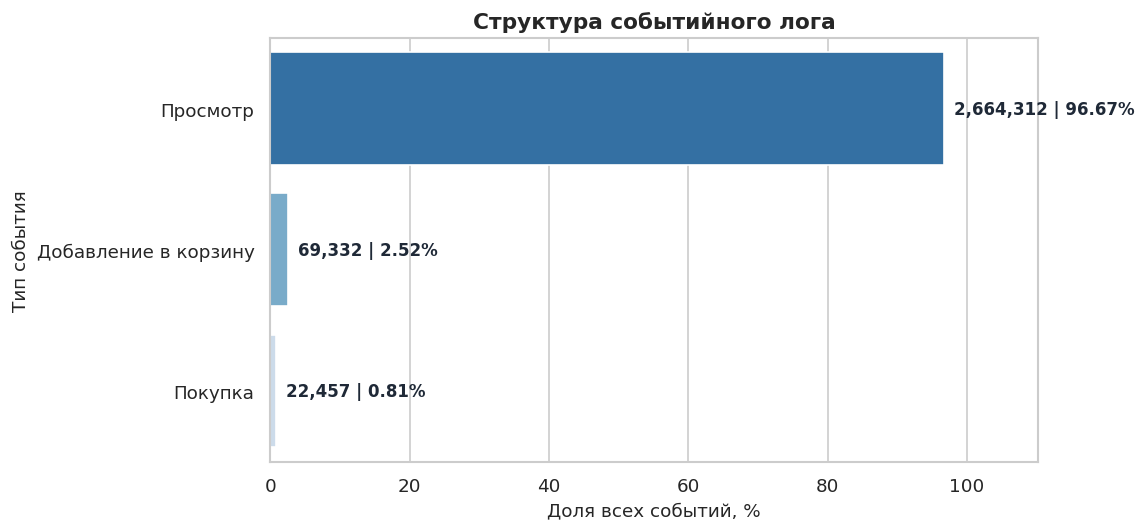

In [25]:
event_mix = (
    pd.DataFrame(notebook_report['event_share_pct'])
    .rename(columns={'event': 'Событие', 'share_pct': 'Доля, %'})
    .assign(Строк=lambda df: df['Событие'].map(eda_summary['event_counts']))
)
event_order = ['view', 'addtocart', 'transaction']
event_labels = {
    'view': 'Просмотр',
    'addtocart': 'Добавление в корзину',
    'transaction': 'Покупка',
}
event_mix['Событие'] = pd.Categorical(event_mix['Событие'], categories=event_order, ordered=True)
event_mix = event_mix.sort_values('Событие')
event_mix['Подпись события'] = event_mix['Событие'].map(event_labels)

fig, ax = plt.subplots(figsize=(9.6, 4.6))
sns.barplot(
    data=event_mix,
    x='Доля, %',
    y='Подпись события',
    hue='Подпись события',
    dodge=False,
    legend=False,
    palette='Blues_r',
    ax=ax,
)
ax.set_xlim(0, event_mix['Доля, %'].max() * 1.14)
for patch, row in zip(ax.patches, event_mix.itertuples(index=False)):
    ax.text(
        patch.get_width() + event_mix['Доля, %'].max() * 0.015,
        patch.get_y() + patch.get_height() / 2,
        f"{fmt_int(row.Строк)} | {fmt_pct(row[1], 2)}",
        va='center',
        ha='left',
        fontsize=10,
        color='#1F2937',
        fontweight='bold',
    )
ax.set_title('Структура событийного лога')
ax.set_xlabel('Доля всех событий, %')
ax.set_ylabel('Тип события')
plt.tight_layout()

display(style_table(event_mix[['Подпись события', 'Строк', 'Доля, %']], formats={'Строк': '{:,.0f}', 'Доля, %': '{:.2f}%'}))


**Выводы блока**

- `View` занимает 96.67% лога (2,664,312 событий), поэтому использовать его как основной target нельзя: сигнал слишком шумный.
- `Addtocart` встречается лишь в 2.52% событий (69,332), но остаётся существенно плотнее, чем `transaction` с 0.81% (22,457).
- Это подтверждает выбор: `view` остаётся контекстом интереса и источником кандидатов, `addtocart` становится основным target, а `transaction` усиливает позитив и помогает фильтровать уже купленное.


## 3. Временное покрытие и split discipline

Здесь важен не только сам диапазон дат, но и устойчивость покрытия по времени. Если последние недели резко отличаются по наполнению от остального лога, time-based split стал бы нестабильным holdout-ом.


Диапазон,Начало,Конец
События,2015-05-03,2015-09-18
Свойства товаров,2015-05-10,2015-09-13
Train-окно,2015-05-03,2015-09-04
Validation-окно,2015-09-04,2015-09-18


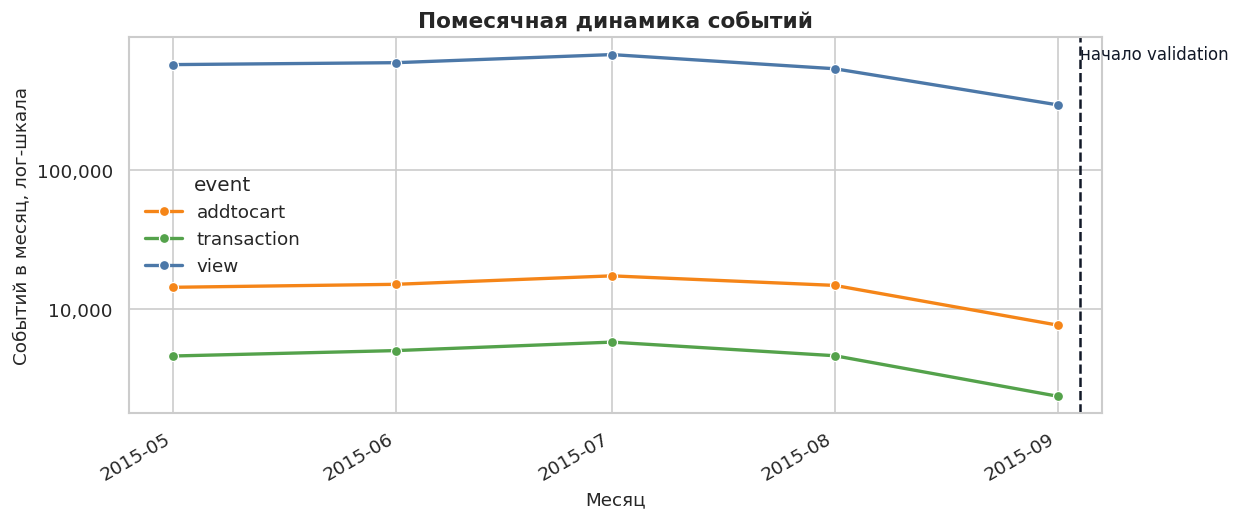

In [5]:
coverage = pd.DataFrame([
    {'Диапазон': 'События', 'Начало': notebook_report['time_coverage']['events_min'], 'Конец': notebook_report['time_coverage']['events_max']},
    {'Диапазон': 'Свойства товаров', 'Начало': notebook_report['time_coverage']['properties_min'], 'Конец': notebook_report['time_coverage']['properties_max']},
    {'Диапазон': 'Train-окно', 'Начало': notebook_report['time_coverage']['events_min'], 'Конец': notebook_report['time_coverage']['train_end']},
    {'Диапазон': 'Validation-окно', 'Начало': notebook_report['time_coverage']['validation_start'], 'Конец': notebook_report['time_coverage']['events_max']},
])
coverage['Начало'] = pd.to_datetime(coverage['Начало'], format='mixed').dt.strftime('%Y-%m-%d')
coverage['Конец'] = pd.to_datetime(coverage['Конец'], format='mixed').dt.strftime('%Y-%m-%d')

monthly = pd.DataFrame(notebook_report['monthly_events'])
monthly['month'] = pd.to_datetime(monthly['month'])
monthly_long = monthly.melt(id_vars='month', var_name='event', value_name='events')

fig, ax = plt.subplots(figsize=(10.5, 4.5))
sns.lineplot(data=monthly_long, x='month', y='events', hue='event', palette=COLORS, marker='o', linewidth=2, ax=ax)
validation_start = pd.to_datetime(notebook_report['time_coverage']['validation_start'])
ax.axvline(validation_start, color='#111827', linestyle='--', linewidth=1.5)
ax.text(validation_start, ax.get_ylim()[1] * 0.88, 'начало validation', color='#111827', fontsize=10)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_title('Помесячная динамика событий')
ax.set_xlabel('Месяц')
ax.set_ylabel('Событий в месяц, лог-шкала')
plt.tight_layout()

display(style_table(coverage))


**Выводы блока**

- События покрывают период с 2015-05-03 по 2015-09-18, а validation начинается 2015-09-04; split действительно отрезает последние 14 дней.
- Пик активности приходится на 2015-07 с 674,820 просмотрами и 17,362 cart-событиями, но месяцы остаются сопоставимыми по масштабу и не ломают holdout.
- Для такого журнала random split дал бы temporal leakage, тогда как time-based validation сохраняет естественный порядок «прошлое → будущее».


## 4. Воронка `view -> addtocart -> transaction`

Переходы между стадиями воронки проверяются на уровне `user-item` пар. Это позволяет отделить общий поток просмотров от действительно ценных действий намерения и покупки.


In [6]:
funnel = pd.DataFrame(notebook_report['funnel_user_item_pairs']).rename(columns={'stage': 'Этап', 'pairs': 'Пары пользователь-товар'})
stage_labels = {
    'all_pairs': 'Все наблюдаемые пары',
    'pairs_with_view': 'Пары с view',
    'pairs_with_addtocart': 'Пары с addtocart',
    'pairs_with_transaction': 'Пары с transaction',
}
funnel['Этап'] = funnel['Этап'].map(stage_labels)
funnel['Доля от всех, %'] = funnel['Пары пользователь-товар'] / funnel.loc[0, 'Пары пользователь-товар'] * 100

conversion = pd.DataFrame(notebook_report['funnel_rates_pct']).rename(columns={'transition': 'Переход', 'rate_pct': 'Конверсия, %'})
conversion['Переход'] = conversion['Переход'].map({
    'view_to_addtocart': 'Просмотр → addtocart',
    'view_to_transaction': 'Просмотр → transaction',
    'addtocart_to_transaction': 'Addtocart → transaction',
})



display(style_table(funnel, formats={'Пары пользователь-товар': '{:,.0f}', 'Доля от всех, %': '{:.2f}%'}))
display(style_table(conversion, formats={'Конверсия, %': '{:.2f}%'}))


Этап,Пары пользователь-товар,"Доля от всех, %"
Все наблюдаемые пары,"2,145,179",100.00%
Пары с view,"2,132,127",99.39%
Пары с addtocart,"62,025",2.89%
Пары с transaction,"21,270",0.99%


Переход,"Конверсия, %"
Просмотр → addtocart,2.32%
Просмотр → transaction,0.89%
Addtocart → transaction,30.71%


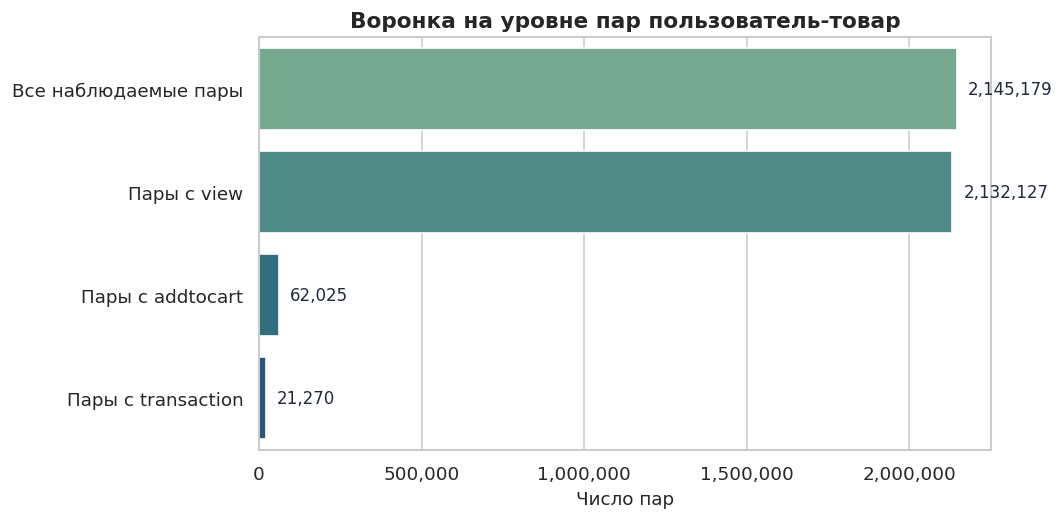

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=funnel, x='Пары пользователь-товар', y='Этап', hue='Этап', dodge=False, legend=False, palette='crest', ax=ax)
annotate_barh(ax, lambda value: fmt_int(value))
ax.set_title('Воронка на уровне пар пользователь-товар')
ax.set_xlabel('Число пар')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()

**Выводы блока**

- Из 2,132,127 просмотренных `user-item` пар только 62,025 переходят в cart: конверсия `view → addtocart` равна 2.32%.
- До транзакции доходит лишь 0.89% просмотренных пар, но уже 30.71% cart-пар завершаются покупкой.
- Это делает `addtocart` хорошим компромиссом между частотой и бизнес-ценностью: сигнал редкий, но тесно связан с последующей покупкой.


## 5. Разреженность по пользователям и товарам

Формат распределения важнее среднего значения: система должна понимать, что большинство пользователей приходит с минимальной историей, а значимая доля товаров встречается лишь несколько раз.


In [8]:
user_bucket = pd.DataFrame(notebook_report['user_activity_buckets']).rename(columns={'activity_bucket': 'Интервал', 'count': 'Пользователи', 'share': 'Доля'})

display(style_table(user_bucket, formats={'Пользователи': '{:,.0f}', 'Доля': '{:.2%}'}, gradient_subset=['Доля']))


Интервал,Пользователи,Доля
1,"1,001,560",71.15%
2-4,"324,400",23.05%
5-9,"58,379",4.15%
10-19,"16,631",1.18%
20-49,"5,344",0.38%
50-99,849,0.06%
100+,417,0.03%


In [9]:
item_bucket = pd.DataFrame(notebook_report['item_activity_buckets']).rename(columns={'activity_bucket': 'Интервал', 'count': 'Товары', 'share': 'Доля'})

display(style_table(item_bucket, formats={'Товары': '{:,.0f}', 'Доля': '{:.2%}'}, gradient_subset=['Доля']))


Интервал,Товары,Доля
1,"73,609",31.31%
2-4,"70,504",29.99%
5-9,"35,820",15.24%
10-19,"24,581",10.46%
20-49,"19,381",8.25%
50-99,"6,945",2.95%
100+,"4,221",1.80%


In [10]:
quantiles = pd.DataFrame([
    {'Сущность': 'Пользователи', 'Медиана событий': eda_summary['user_stats']['median_events_per_user'], 'P95': eda_summary['user_stats']['p95_events_per_user'], 'P99': eda_summary['user_stats']['p99_events_per_user']},
    {'Сущность': 'Товары', 'Медиана событий': eda_summary['item_stats']['median_events_per_item'], 'P95': eda_summary['item_stats']['p95_events_per_item'], 'P99': eda_summary['item_stats']['p99_events_per_item']},
])

style_table(quantiles, formats={'Медиана событий': '{:,.0f}', 'P95': '{:,.0f}', 'P99': '{:,.0f}'})

Сущность,Медиана событий,P95,P99
Пользователи,1,5,13
Товары,3,47,143


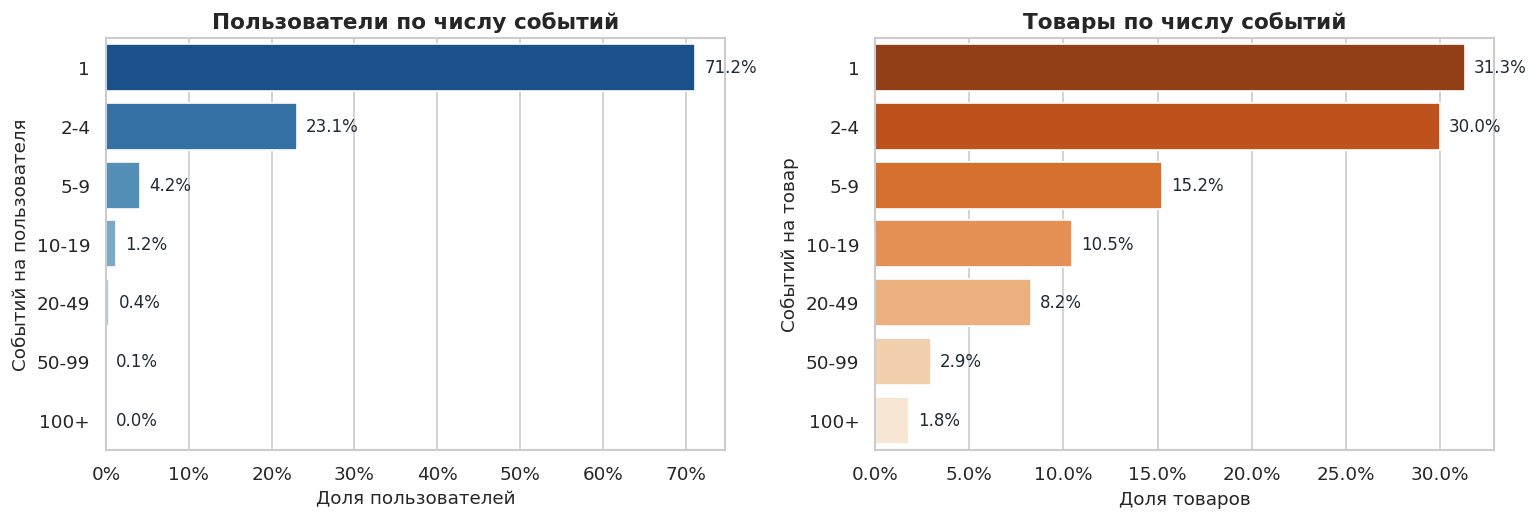

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=False)
sns.barplot(data=user_bucket, x='Доля', y='Интервал', hue='Интервал', dodge=False, legend=False, palette='Blues_r', ax=axes[0])
annotate_barh(axes[0], lambda value: fmt_pct(value * 100, 1))
axes[0].set_title('Пользователи по числу событий')
axes[0].set_xlabel('Доля пользователей')
axes[0].set_ylabel('Событий на пользователя')
axes[0].xaxis.set_major_formatter(PercentFormatter(1.0))

sns.barplot(data=item_bucket, x='Доля', y='Интервал', hue='Интервал', dodge=False, legend=False, palette='Oranges_r', ax=axes[1])
annotate_barh(axes[1], lambda value: fmt_pct(value * 100, 1))
axes[1].set_title('Товары по числу событий')
axes[1].set_xlabel('Доля товаров')
axes[1].set_ylabel('Событий на товар')
axes[1].xaxis.set_major_formatter(PercentFormatter(1.0))
plt.tight_layout()

**Выводы блока**

- 71.15% пользователей имеют ровно одно событие; медиана по пользователю равна 1.0, а 95-й перцентиль — всего 5.0.
- Даже по товарам long tail выражен сильно: 61.30% item-ов наблюдаются не более четырёх раз.
- Это означает, что сложная персонализация без fallback будет часто работать на слишком короткой истории, а dense user-item представление окажется почти пустым.


## 6. Long-tail и repeat-interest

Далее важно отделить две разные инженерные гипотезы: насколько сильным должен быть popularity fallback и насколько реален повторный интерес к уже знакомым товарам.


In [12]:
item_counts = events.groupby('itemid', observed=True).size().sort_values(ascending=False).reset_index(drop=True)
cumulative_share = item_counts.cumsum() / item_counts.sum()
points = np.unique(np.geomspace(1, len(item_counts), num=120).astype(int))
long_tail_curve = pd.DataFrame({
    'Топ товаров': points,
    'Накопленная доля событий': cumulative_share.iloc[points - 1].values,
})
reference_points = pd.DataFrame(notebook_report['long_tail_curve']).rename(columns={'top_n': 'Топ товаров', 'event_share_pct': 'Доля событий, %'})


display(style_table(reference_points, formats={'Топ товаров': '{:,.0f}', 'Доля событий, %': '{:.2f}%'}))



Топ товаров,"Доля событий, %"
10,0.75%
100,3.62%
"1,000",14.31%
"5,000",33.65%
"10,000",46.10%


In [13]:
repeat_interest = pd.DataFrame(notebook_report['repeat_interest']).rename(columns={'metric': 'Метрика', 'value_pct': 'Значение, %'})
repeat_interest['Метрика'] = repeat_interest['Метрика'].map({
    'repeat_views_share_pct': 'Пары с повторными просмотрами',
    'repeat_carts_share_pct': 'Пары с повторными cart-событиями',
    'aggregated_pairs_with_any_cart_pct': 'Пары с любым cart-сигналом',
    'aggregated_pairs_with_any_transaction_pct': 'Пары с любым transaction-сигналом',
})
style_table(repeat_interest, formats={'Значение, %': '{:.2f}%'} , gradient_subset=['Значение, %'])

Метрика,"Значение, %"
Пары с повторными просмотрами,14.29%
Пары с повторными cart-событиями,0.24%
Пары с любым cart-сигналом,2.89%
Пары с любым transaction-сигналом,1.00%


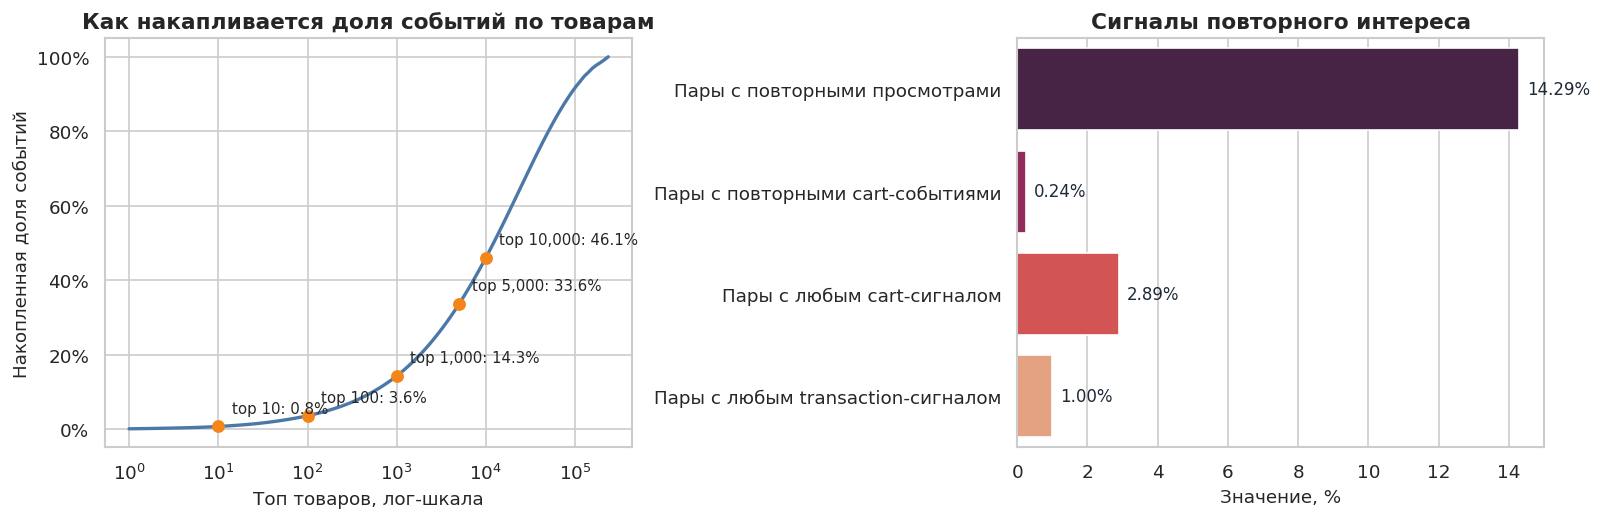

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5))
axes[0].plot(long_tail_curve['Топ товаров'], long_tail_curve['Накопленная доля событий'], color='#4C78A8', linewidth=2)
axes[0].scatter(reference_points['Топ товаров'], reference_points['Доля событий, %'] / 100, color='#F58518', s=45, zorder=3)
for row in reference_points.itertuples(index=False):
    axes[0].annotate(f"top {row[0]:,}: {row[1]:.1f}%", (row[0], row[1] / 100), xytext=(8, 8), textcoords='offset points', fontsize=9)
axes[0].set_xscale('log')
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].set_title('Как накапливается доля событий по товарам')
axes[0].set_xlabel('Топ товаров, лог-шкала')
axes[0].set_ylabel('Накопленная доля событий')

sns.barplot(data=repeat_interest, x='Значение, %', y='Метрика', hue='Метрика', dodge=False, legend=False, palette='rocket', ax=axes[1])
annotate_barh(axes[1], lambda value: fmt_pct(value, 2))
axes[1].set_title('Сигналы повторного интереса')
axes[1].set_xlabel('Значение, %')
axes[1].set_ylabel('')
plt.tight_layout()

**Выводы блока**

- Даже top-100 товаров объясняют лишь 3.62% событий, а top-10,000 — 46.10%; одного popularity baseline для retrieval явно недостаточно.
- При этом повторный интерес реален: 14.29% `user-item` пар имеют повторные просмотры.
- Cart-сигнал остаётся редким: только 2.89% агрегированных пар имеют хотя бы один cart и 0.24% — повторный cart. Поэтому персонализация должна опираться на историю, но не ожидать от неё высокой плотности.


## 7. Покрытие и ограничения `item_properties`

Полезность `item_properties` определяется не только размером таблицы, но и тем, насколько snapshot пересекается с ценными событиями в логе. Для архитектуры важно понять, стоит ли делать из свойств центральный источник признаков.


In [15]:
properties = notebook_report['item_properties_coverage']
coverage_table = pd.DataFrame([
    {'Метрика': 'Покрытие событийного каталога снимком', 'Значение, %': properties['event_item_coverage_pct']},
    {'Метрика': 'Покрытие строк событий снимком', 'Значение, %': properties['event_row_coverage_pct']},
    {'Метрика': 'Покрытие строк addtocart снимком', 'Значение, %': properties['addtocart_row_coverage_pct']},
    {'Метрика': 'Покрытие строк transaction снимком', 'Значение, %': properties['transaction_row_coverage_pct']},
    {'Метрика': 'Доля строк с available = 0 в снимке', 'Значение, %': properties['available_zero_share_pct']},
])

display(style_table(coverage_table, formats={'Значение, %': '{:.2f}%'} , gradient_subset=['Значение, %']))



Метрика,"Значение, %"
Покрытие событийного каталога снимком,78.81%
Покрытие строк событий снимком,90.73%
Покрытие строк addtocart снимком,98.80%
Покрытие строк transaction снимком,97.88%
Доля строк с available = 0 в снимке,87.05%


In [16]:
overlap_table = pd.DataFrame([
    {'Метрика': 'Товары только в events', 'Значение': properties['items_only_in_events']},
    {'Метрика': 'Товары только в item_properties', 'Значение': properties['items_only_in_properties']},
    {'Метрика': 'Медиана версий на пару item-property', 'Значение': eda_summary['item_properties']['median_versions_per_item_property']},
    {'Метрика': 'P95 версий на пару item-property', 'Значение': eda_summary['item_properties']['p95_versions_per_item_property']},
])
display(style_table(overlap_table, formats={'Значение': '{:,.0f}'}))


Метрика,Значение
Товары только в events,"49,815"
Товары только в item_properties,"231,807"
Медиана версий на пару item-property,1
P95 версий на пару item-property,1


In [17]:
top_item_coverage = pd.DataFrame(properties['top_item_snapshot_coverage']).rename(columns={'top_n': 'Топ товаров', 'snapshot_item_coverage': 'Покрытие снимка' })

style_table(top_item_coverage, formats={'Топ товаров': '{:,.0f}', 'Покрытие снимка': '{:.2%}'})

Топ товаров,Покрытие снимка
100,99.00%
"1,000",96.40%
"5,000",96.00%
"10,000",95.21%


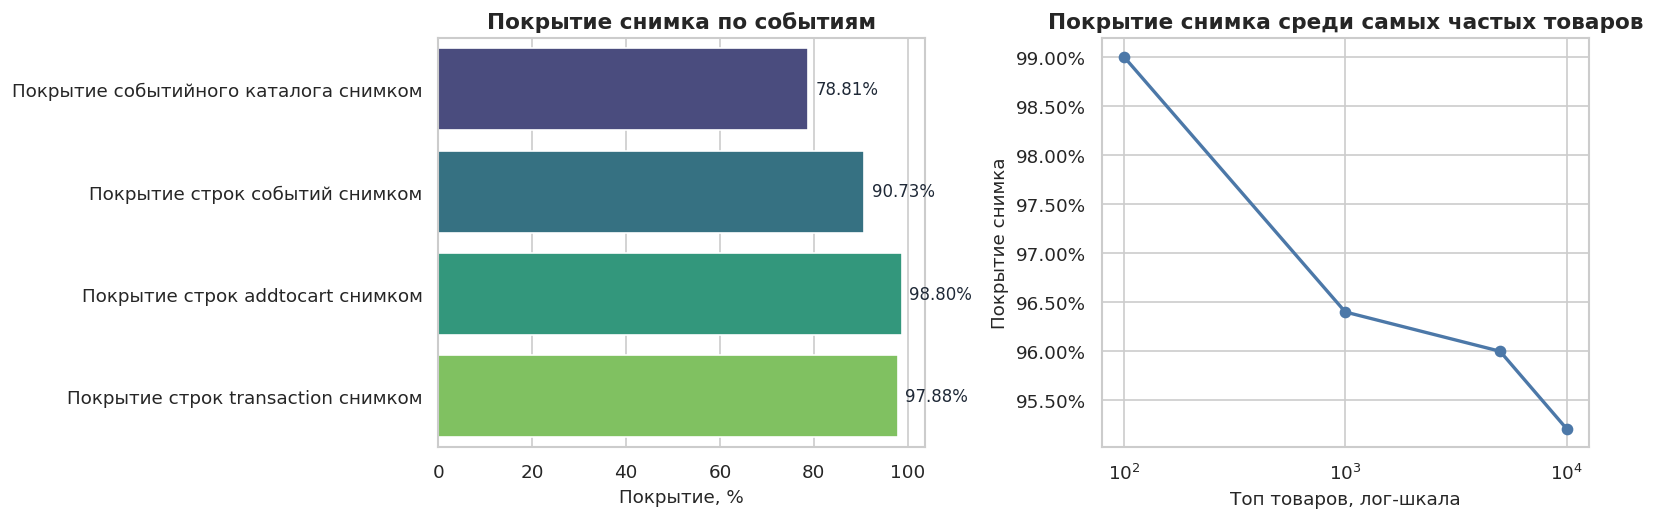

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5))
sns.barplot(data=coverage_table.iloc[:4], x='Значение, %', y='Метрика', hue='Метрика', dodge=False, legend=False, palette='viridis', ax=axes[0])
annotate_barh(axes[0], lambda value: fmt_pct(value, 2))
axes[0].set_title('Покрытие снимка по событиям')
axes[0].set_xlabel('Покрытие, %')
axes[0].set_ylabel('')

axes[1].plot(top_item_coverage['Топ товаров'], top_item_coverage['Покрытие снимка'], marker='o', color='#4C78A8', linewidth=2)
axes[1].set_xscale('log')
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].set_title('Покрытие снимка среди самых частых товаров')
axes[1].set_xlabel('Топ товаров, лог-шкала')
axes[1].set_ylabel('Покрытие снимка')
plt.tight_layout()

**Выводы блока**

- Snapshot покрывает только 78.81% товаров из событийного каталога, поэтому item features не могут быть обязательной основой модели.
- Для более ценных сигналов coverage намного выше: 98.80% строк `addtocart` и 97.88% строк `transaction` имеют snapshot-признаки.
- Среди top-100 самых частых товаров snapshot покрывает 99.0% каталога, поэтому `categoryid` и `available` разумно использовать как лёгкий фильтр и вспомогательный контекст, но не как широкий feature space.


## 8. Memory-safe инженерные ограничения

Финальный EDA должен не только объяснять модельные решения, но и показывать, как они укладываются в локальные инженерные ограничения проекта.


In [19]:
memory_footprint = pd.DataFrame(notebook_report['memory_footprint']).rename(columns={'frame': 'Артефакт', 'rows': 'Строк', 'memory_mb': 'Память, МБ'})
memory_footprint['Назначение'] = ['Источник событий для анализа', 'Агрегация user-item для моделирования', 'Компактный снимок товаров для фильтров']

display(style_table(memory_footprint, formats={'Строк': '{:,.0f}', 'Память, МБ': '{:.2f}'}))




Артефакт,Строк,"Память, МБ",Назначение
events_prepared,"2,756,101",55.20,Источник событий для анализа
aggregated_train,"1,950,423",48.36,Агрегация user-item для моделирования
item_snapshot,"417,053",3.58,Компактный снимок товаров для фильтров


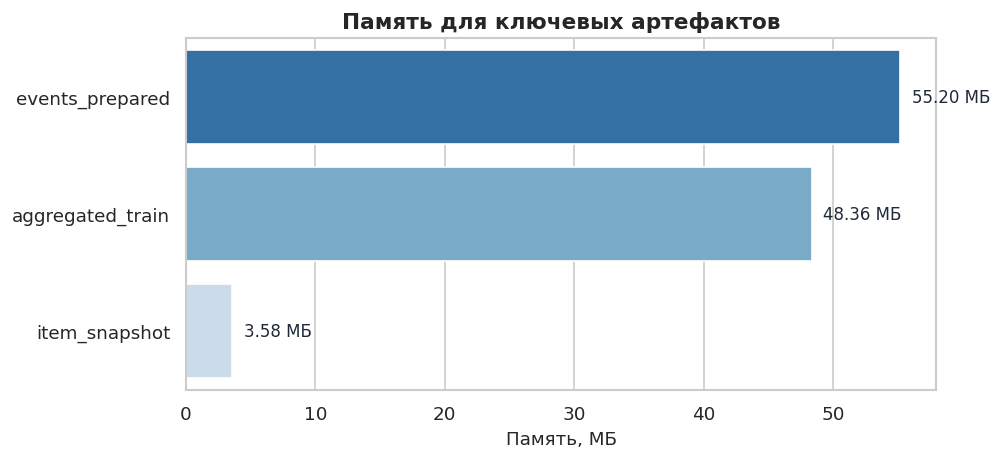

In [20]:
fig, ax = plt.subplots(figsize=(8.5, 4))
sns.barplot(data=memory_footprint, x='Память, МБ', y='Артефакт', hue='Артефакт', dodge=False, legend=False, palette='Blues_r', ax=ax)
annotate_barh(ax, lambda value: f'{value:.2f} МБ')
ax.set_title('Память для ключевых артефактов')
ax.set_xlabel('Память, МБ')
ax.set_ylabel('')
plt.tight_layout();

## 9. Выводы для проектирования рекомендательной системы

1. `Addtocart` выбран как основной target, потому что занимает 2.52% лога, но при этом ведёт к покупке в 30.71% cart-пар.
2. Split должен быть строго `time-based`: события покрывают период 2015-05-03 → 2015-09-18, а validation отделяет последние 14 дней без leakage.
3. Fallback обязателен: 71.15% пользователей имеют только одно событие, а медианный профиль по уникальным items равен 1.
4. Один popularity baseline недостаточен: top-100 товаров объясняют лишь 3.62% событий, поэтому retrieval должен уметь выходить за пределы короткого head-каталога.
5. `Item_properties` полезны точечно: snapshot покрывает 98.80% cart-событий, но только 78.81% товаров событийного каталога.
6. Пайплайн должен оставаться memory-safe: рабочие artifacts укладываются примерно в 107.1 MB, а значит решение можно локально воспроизводить без тяжёлой инфраструктуры.
